# BINDS: un modelo multimodal para cáncer de mama, examinado por dentro

> **AUROC 0,973.** Suena perfecto. ¿Pero qué tan bueno es eso *de verdad*?

Un equipo en China entrenó un modelo (BINDS) que combina tres tipos de imágenes — ecografía, mamografía y resonancia — para diagnosticar cáncer de mama sin necesidad de biopsia. El paper anuncia un AUROC de 0,973 sobre 27.048 pacientes. Bajamos los datos del propio paper y miramos qué tan robusto es ese número cuando lo desmenuzamos.

📄 **Paper:** [10.1038/s41551-026-01654-2](https://doi.org/10.1038/s41551-026-01654-2) · *Nature Biomedical Engineering*, 2026
🔗 **Video:** [Pendiente]
🚀 **Reproducir:** [![Abrir en Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/Ciencia-a-Mordiscos/lab/blob/main/papers/2026-05-19-binds-cancer-mama-ia/notebook.ipynb)

## El experimento

BINDS entrena con tres modalidades de imagen mamaria que típicamente se ordenan en cascada en la clínica:

- **US** — ultrasonido (la prueba más barata, primera línea).
- **MM** — mamografía (cribado estándar).
- **MRI** — resonancia magnética (cara, solo casos seleccionados).

El modelo es flexible: puede operar con una sola modalidad, con dos, o con las tres. BINDS se validó en una cohorte externa de varios centros y el AUROC headline llegó a **0,973**.

Hay tres cosas que vale la pena mirar con calma:

1. ¿Cuánto sube el modelo cuando le das modalidades adicionales?
2. ¿Qué tan estable es el AUC cuando bajamos a casos clínicamente difíciles?
3. ¿Cuántos datos necesita BINDS para llegar al techo?

Vamos a abrir los Source Data del paper (MOESM3, MOESM4 y MOESM7) y responder cada una.

In [1]:
# ══════════════════════════════════════════════════════════════
# Configuración — modifica estos valores para explorar
# ══════════════════════════════════════════════════════════════
HEADLINE_AUC = 0.973         # AUROC overall (subgrupo "Overall" en fig3c)
HEADLINE_CI = (0.964, 0.981)
AUC_US_SOLO = 0.876          # external AUROC con ultrasonido solo
N_PARTICIPANTES = 27048

FUENTE = "Fuente: Liu et al. (2026), Nat. Biomed. Eng. | Datos: MOESM3/4/7"
COLOR_DATOS = "#2563EB"      # azul CaM (datos principales)
COLOR_ALERTA = "#DC2626"     # rojo (headline, alerta)
COLOR_SECUNDARIO = "#059669" # emerald (segunda serie)
COLOR_REFERENCIA = "#D97706" # ámbar (referencia)
COLOR_GRIS = "#BBBBBB"

# ══════════════════════════════════════════════════════════════
# Setup
# ══════════════════════════════════════════════════════════════
import os, urllib.request
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

style_file = "../../cam.mplstyle"
if not os.path.exists(style_file):
    style_file = "/tmp/cam.mplstyle"
    if not os.path.exists(style_file):
        urllib.request.urlretrieve(
            "https://raw.githubusercontent.com/Ciencia-a-Mordiscos/lab/main/cam.mplstyle",
            style_file,
        )
plt.style.use(style_file)

# ══════════════════════════════════════════════════════════════
# Carga de los Source Data del paper
# ══════════════════════════════════════════════════════════════
modalidad = pd.read_csv("datos/auroc_riesgo_por_modalidad.csv")
subgrupos = pd.read_csv("datos/desempeno_por_subgrupo.csv")
eficiencia = pd.read_csv("datos/eficiencia_datos_entrenamiento.csv")
masking = pd.read_csv("datos/ablacion_random_masking.csv")
subtipo = pd.read_csv("datos/auroc_subtipo_por_modalidad.csv")

print(f"Modalidades: {len(modalidad)} combinaciones")
print(f"Subgrupos clínicos: {len(subgrupos)} categorías")
print(f"Ablation de datos: {len(eficiencia)} puntos (% training data)")
print(f"Ablation random masking: {len(masking)//2} pares")
print(f"\nHeadline del paper: AUROC = {HEADLINE_AUC} (CI {HEADLINE_CI[0]}–{HEADLINE_CI[1]})")

Modalidades: 7 combinaciones
Subgrupos clínicos: 13 categorías
Ablation de datos: 5 puntos (% training data)
Ablation random masking: 4 pares

Headline del paper: AUROC = 0.973 (CI 0.964–0.981)


## Lo que muestran los datos cuando los pones lado a lado

Aquí está cada modalidad por separado y cada combinación. La línea roja es el headline.

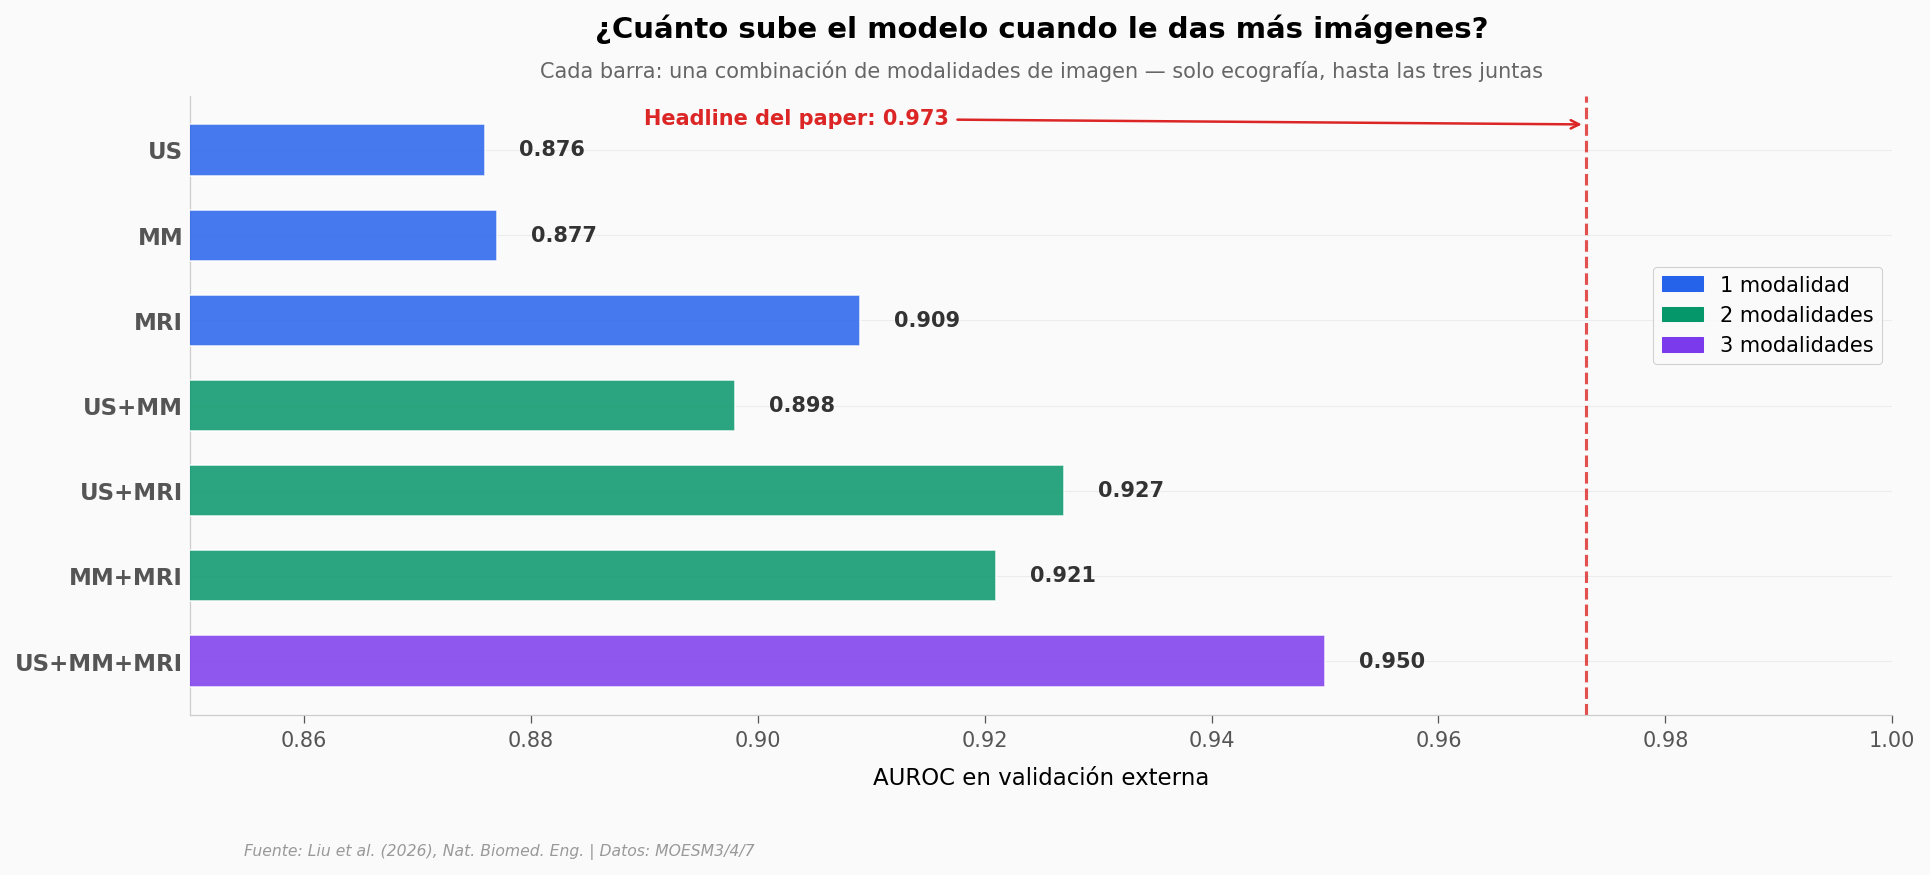

In [2]:
# Gráfica 1 — AUROC external por modalidad y combinación
fig, ax = plt.subplots(figsize=(13, 5.5))

orden = ["US", "MM", "MRI", "US+MM", "US+MRI", "MM+MRI", "US+MM+MRI"]
mod_df = modalidad.set_index("modalidad").loc[orden].reset_index()
n_modalidades = mod_df["modalidad"].str.count(r"\+") + 1
colors = [COLOR_DATOS if n == 1 else COLOR_SECUNDARIO if n == 2 else "#7C3AED" for n in n_modalidades]

y_pos = np.arange(len(mod_df))[::-1]
ax.barh(y_pos, mod_df["external_auroc"], color=colors, height=0.6, alpha=0.85,
        edgecolor="white", linewidth=0.8, zorder=3)

# Etiquetas de AUC al final de cada barra
for y, v in zip(y_pos, mod_df["external_auroc"]):
    ax.text(v + 0.003, y, f"{v:.3f}", va="center", fontsize=10, fontweight="bold", color="#333333")

ax.set_yticks(y_pos)
ax.set_yticklabels(mod_df["modalidad"], fontsize=11, fontweight="bold")
ax.set_xlim(0.85, 1.0)
ax.set_xlabel("AUROC en validación externa", fontsize=11)
ax.set_title("¿Cuánto sube el modelo cuando le das más imágenes?",
             fontsize=14, fontweight="bold", pad=28)
ax.text(0.5, 1.03, "Cada barra: una combinación de modalidades de imagen — solo ecografía, hasta las tres juntas",
        transform=ax.transAxes, fontsize=10, color="#666666", ha="center")

# Línea del headline 0,973
ax.axvline(x=HEADLINE_AUC, color=COLOR_ALERTA, linewidth=1.5, linestyle="--", alpha=0.8, zorder=2)
ax.annotate(f"Headline del paper: {HEADLINE_AUC}",
            xy=(HEADLINE_AUC, 6.3), xytext=(0.89, 6.3),
            fontsize=10, fontweight="bold", color=COLOR_ALERTA,
            arrowprops=dict(arrowstyle="->", color=COLOR_ALERTA, lw=1.2))

# Leyenda de color por número de modalidades (sin solapar la barra US+MM+MRI)
from matplotlib.patches import Patch
ax.legend(
    handles=[
        Patch(color=COLOR_DATOS, label="1 modalidad"),
        Patch(color=COLOR_SECUNDARIO, label="2 modalidades"),
        Patch(color="#7C3AED", label="3 modalidades"),
    ],
    loc="lower right", bbox_to_anchor=(1.0, 0.55), fontsize=10, frameon=True, framealpha=0.92,
)

fig.text(0.13, -0.05, FUENTE, fontsize=7.5, color="#999999", style="italic")
plt.tight_layout()
plt.savefig("figuras/01_auroc_por_modalidad.png", dpi=200, bbox_inches="tight")
plt.show()

**Lectura.** Con ultrasonido solo —la prueba más accesible— BINDS llega a 0,876. Añadir mamografía suma 2,2 puntos porcentuales (0,898). Añadir resonancia salta al rango 0,92–0,95. La diferencia entre la mejor modalidad única (MRI = 0,909) y las tres combinadas (0,950) es de **4,1 puntos porcentuales**. Es una mejora real, pero los retornos por modalidad adicional se aplanan.

El número de 0,973 del headline no aparece aquí. Vive en otro escenario, el de validación con todas las modalidades disponibles más un esquema two-stage del que hablaremos al final.

## ¿Y cuando el caso es difícil?

En radiología mamaria existe la escala **BI-RADS** (Breast Imaging Reporting and Data System) — clasifica lesiones del 1 (normal) al 5 (alta sospecha). El subtipo **4A** es probablemente el más conflictivo del día a día: lesión con baja sospecha pero suficiente para considerar biopsia. Aquí es donde un sistema como BINDS, si funciona, debería brillar — ahorrarle al paciente una biopsia innecesaria.

Veamos cómo se comporta el modelo en cada subgrupo.

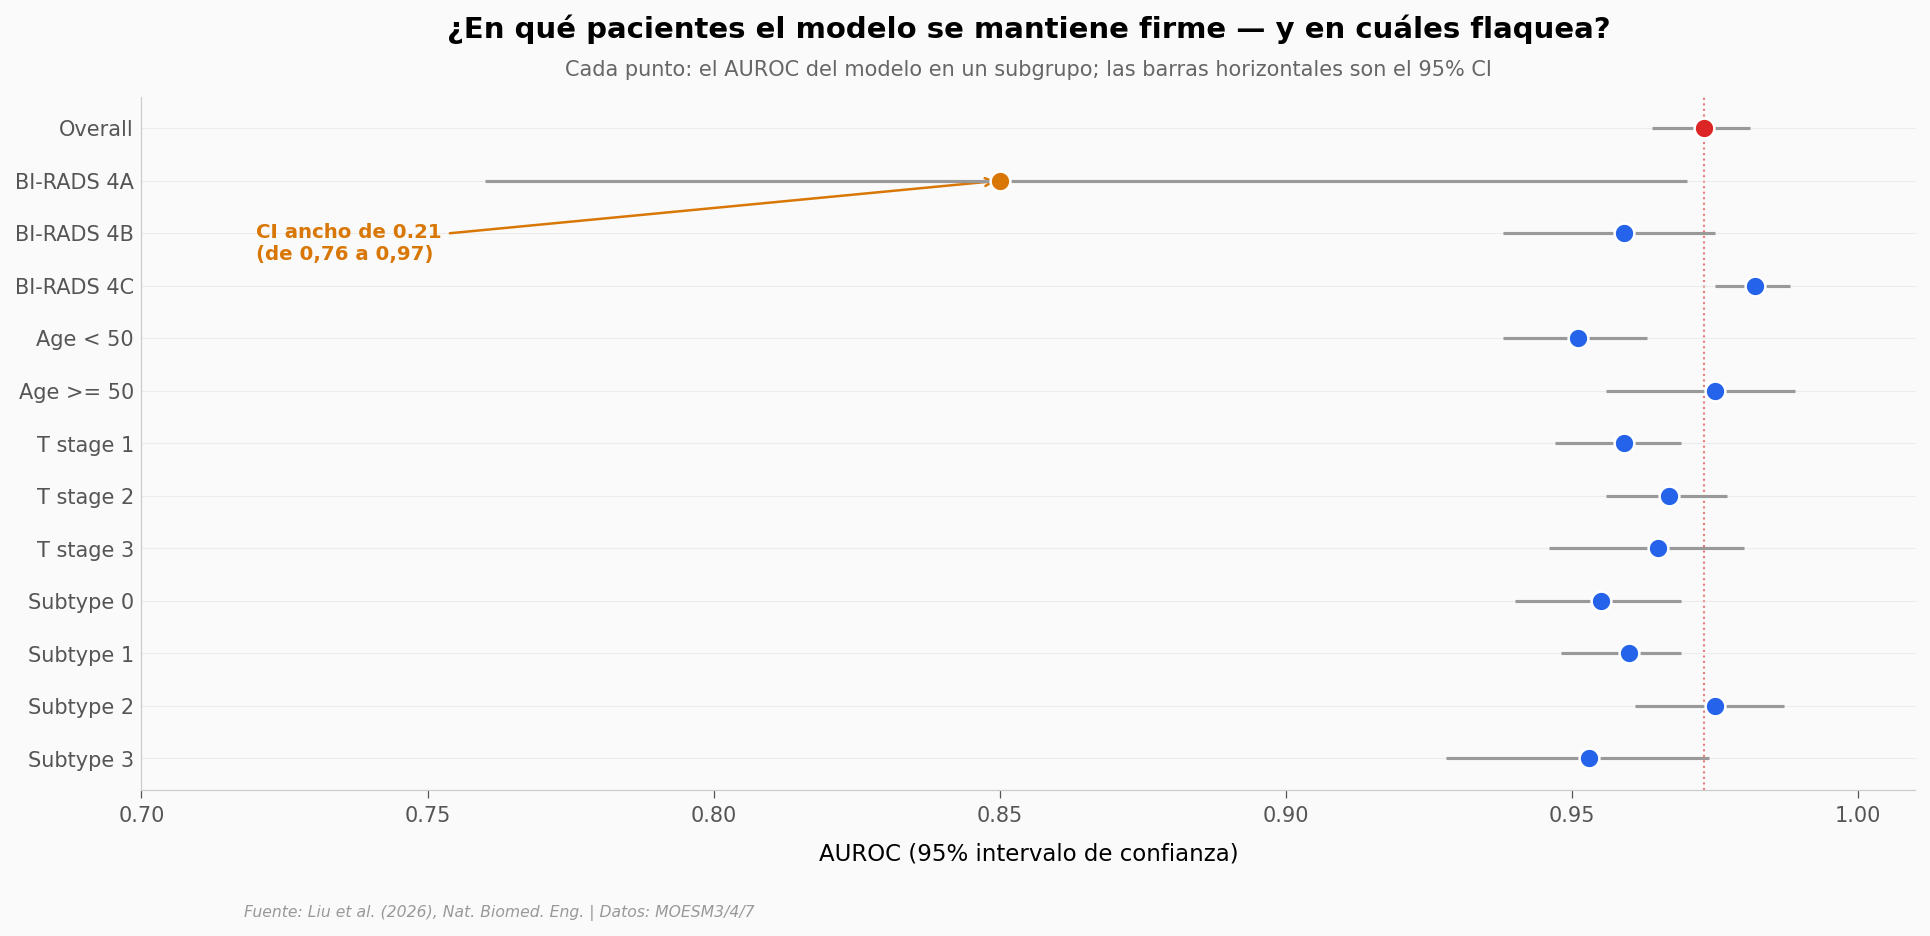

In [3]:
# Gráfica 2 — Forest plot AUC con 95% CI por subgrupo clínico
fig, ax = plt.subplots(figsize=(13, 6))

# Orden lógico: Overall arriba, BI-RADS en medio, edad/T-stage/subtipo abajo
orden_sub = ["Overall", "BI-RADS 4A", "BI-RADS 4B", "BI-RADS 4C",
             "Age < 50", "Age >= 50",
             "T stage 1", "T stage 2", "T stage 3",
             "Subtype 0", "Subtype 1", "Subtype 2", "Subtype 3"]
sub_df = subgrupos.set_index("subgrupo").loc[orden_sub].reset_index()

y_pos = np.arange(len(sub_df))[::-1]
err_low = sub_df["auc_roc"] - sub_df["auc_roc_lower"]
err_up = sub_df["auc_roc_upper"] - sub_df["auc_roc"]

# Resaltar Overall (rojo) y BI-RADS 4A (alerta)
colors = []
for s in sub_df["subgrupo"]:
    if s == "Overall":
        colors.append(COLOR_ALERTA)
    elif s == "BI-RADS 4A":
        colors.append(COLOR_REFERENCIA)
    else:
        colors.append(COLOR_DATOS)

ax.errorbar(sub_df["auc_roc"], y_pos,
            xerr=[err_low, err_up],
            fmt="o", markersize=8, capsize=4, capthick=1.5, linewidth=1.5,
            ecolor="#999999",
            color="none",
            markeredgewidth=0, zorder=4)
# Marcadores encima con color
for i, (auc, y, c) in enumerate(zip(sub_df["auc_roc"], y_pos, colors)):
    ax.scatter([auc], [y], color=c, s=90, edgecolors="white", linewidths=1.2, zorder=5)

ax.set_yticks(y_pos)
ax.set_yticklabels(sub_df["subgrupo"], fontsize=10)
ax.set_xlim(0.70, 1.01)
ax.set_xlabel("AUROC (95% intervalo de confianza)", fontsize=11)
ax.set_title("¿En qué pacientes el modelo se mantiene firme — y en cuáles flaquea?",
             fontsize=14, fontweight="bold", pad=28)
ax.text(0.5, 1.03, "Cada punto: el AUROC del modelo en un subgrupo; las barras horizontales son el 95% CI",
        transform=ax.transAxes, fontsize=10, color="#666666", ha="center")

# Línea de referencia en 0.973
ax.axvline(x=HEADLINE_AUC, color=COLOR_ALERTA, linewidth=1, linestyle=":", alpha=0.6, zorder=1)

# Anotación BI-RADS 4A
y_4a = list(sub_df["subgrupo"]).index("BI-RADS 4A")
y_4a = y_pos[y_4a]
ancho_ci_4a = float(sub_df.loc[sub_df["subgrupo"] == "BI-RADS 4A", "auc_roc_upper"].iloc[0]) - float(sub_df.loc[sub_df["subgrupo"] == "BI-RADS 4A", "auc_roc_lower"].iloc[0])
ax.annotate(f"CI ancho de {ancho_ci_4a:.2f}\n(de 0,76 a 0,97)",
            xy=(0.85, y_4a), xytext=(0.72, y_4a - 1.5),
            fontsize=9.5, fontweight="bold", color=COLOR_REFERENCIA,
            arrowprops=dict(arrowstyle="->", color=COLOR_REFERENCIA, lw=1.2))

fig.text(0.13, -0.03, FUENTE, fontsize=7.5, color="#999999", style="italic")
plt.tight_layout()
plt.savefig("figuras/02_subgrupos_forest.png", dpi=200, bbox_inches="tight")
plt.show()

## La sorpresa: cuántos datos necesita BINDS

Un modelo de deep learning sobre 27.000 pacientes y 7 datasets públicos es caro de juntar. Una pregunta práctica es: ¿cuánto del techo se alcanza con menos datos?

El paper corrió el experimento entrenando BINDS con 10%, 25%, 50%, 75% y 100% de los datos. Una modalidad se satura mucho antes que las otras.

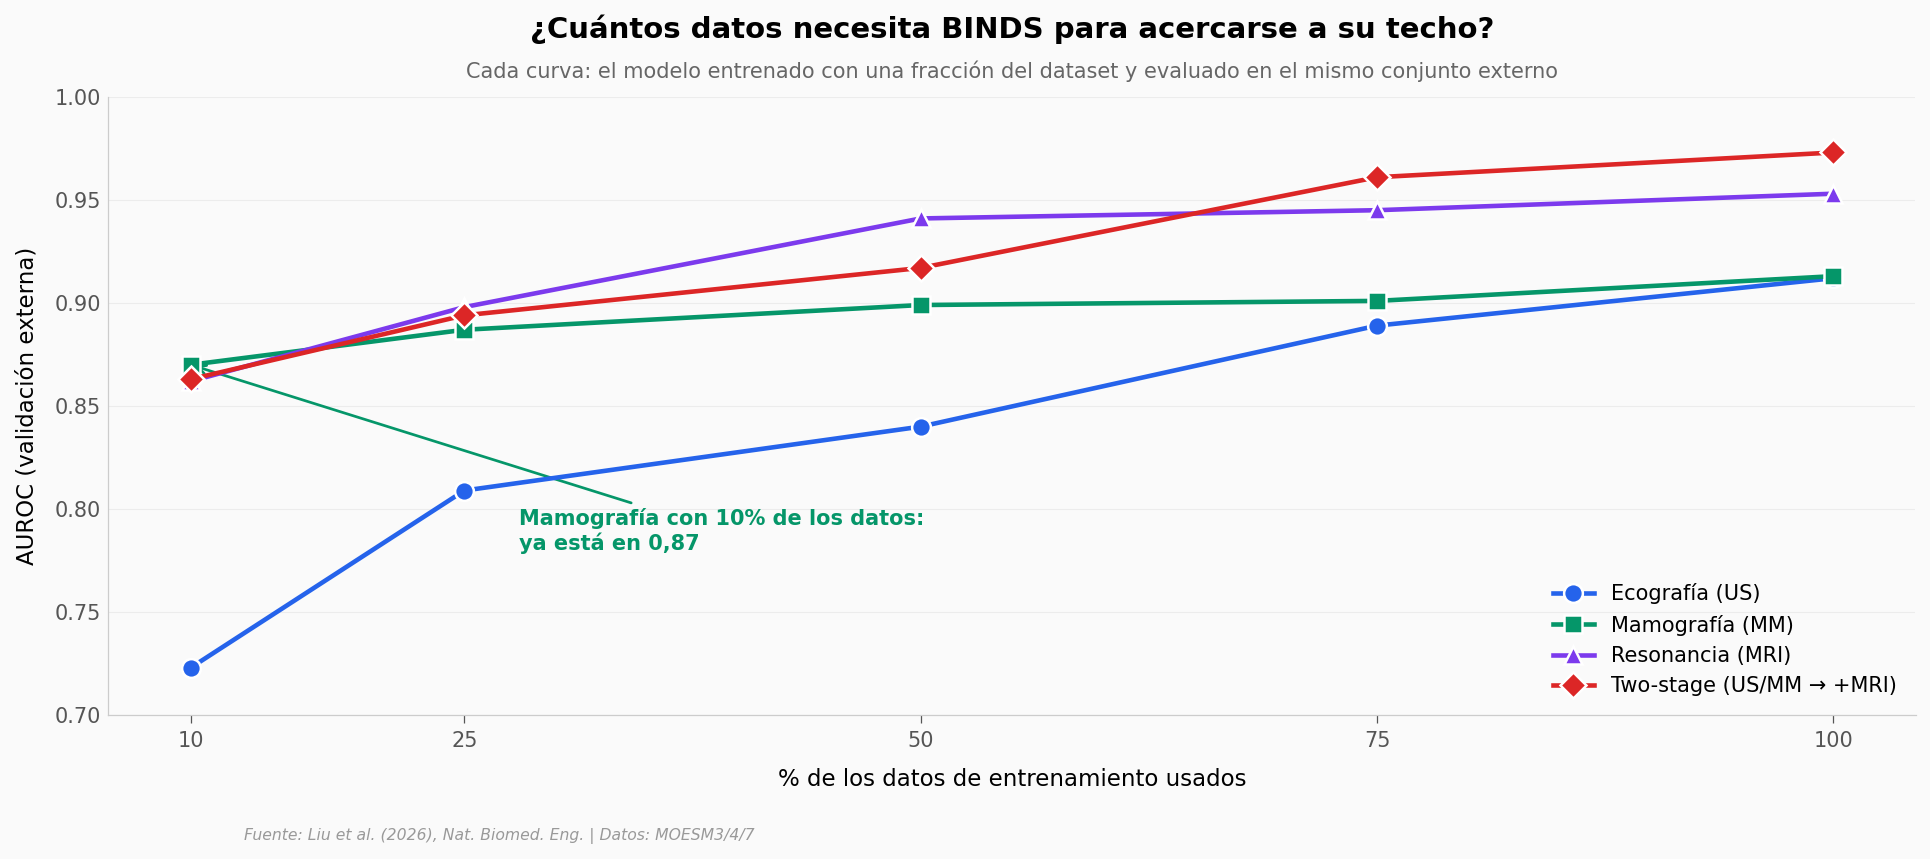

In [4]:
# Gráfica 3 — AUROC vs % training data por modalidad
fig, ax = plt.subplots(figsize=(13, 5.5))

x = eficiencia["training_data_pct"]
series = [
    ("us_auroc", "Ecografía (US)", COLOR_DATOS, "o"),
    ("mm_auroc", "Mamografía (MM)", COLOR_SECUNDARIO, "s"),
    ("mri_auroc", "Resonancia (MRI)", "#7C3AED", "^"),
    ("two_stage_auroc", "Two-stage (US/MM → +MRI)", COLOR_ALERTA, "D"),
]

for col, label, color, marker in series:
    ax.plot(x, eficiencia[col], color=color, linewidth=2.2, marker=marker,
            markersize=9, markeredgecolor="white", markeredgewidth=1.2,
            label=label, zorder=4)

# Marcar punto clave: MM 10% → 0,87
ax.annotate("Mamografía con 10% de los datos:\nya está en 0,87",
            xy=(10, 0.87), xytext=(28, 0.78),
            fontsize=10, fontweight="bold", color=COLOR_SECUNDARIO,
            arrowprops=dict(arrowstyle="->", color=COLOR_SECUNDARIO, lw=1.3))

ax.set_xlabel("% de los datos de entrenamiento usados", fontsize=11)
ax.set_ylabel("AUROC (validación externa)", fontsize=11)
ax.set_title("¿Cuántos datos necesita BINDS para acercarse a su techo?",
             fontsize=14, fontweight="bold", pad=28)
ax.text(0.5, 1.03, "Cada curva: el modelo entrenado con una fracción del dataset y evaluado en el mismo conjunto externo",
        transform=ax.transAxes, fontsize=10, color="#666666", ha="center")

ax.set_xticks([10, 25, 50, 75, 100])
ax.set_ylim(0.70, 1.0)
ax.legend(loc="lower right", fontsize=10, framealpha=0.95)

fig.text(0.13, -0.03, FUENTE, fontsize=7.5, color="#999999", style="italic")
plt.tight_layout()
plt.savefig("figuras/03_eficiencia_datos.png", dpi=200, bbox_inches="tight")
plt.show()

## ¿Qué tan alto está el headline dentro del propio paper?

El 0,973 no es un resumen del modelo. Es **un** AUC, en **un** subgrupo (Overall), bajo **un** escenario (validación externa con todas las modalidades disponibles, esquema two-stage). El paper reporta decenas de AUCs distintos en sus Source Data. Lo apilamos todos en una distribución para ver dónde cae el headline.

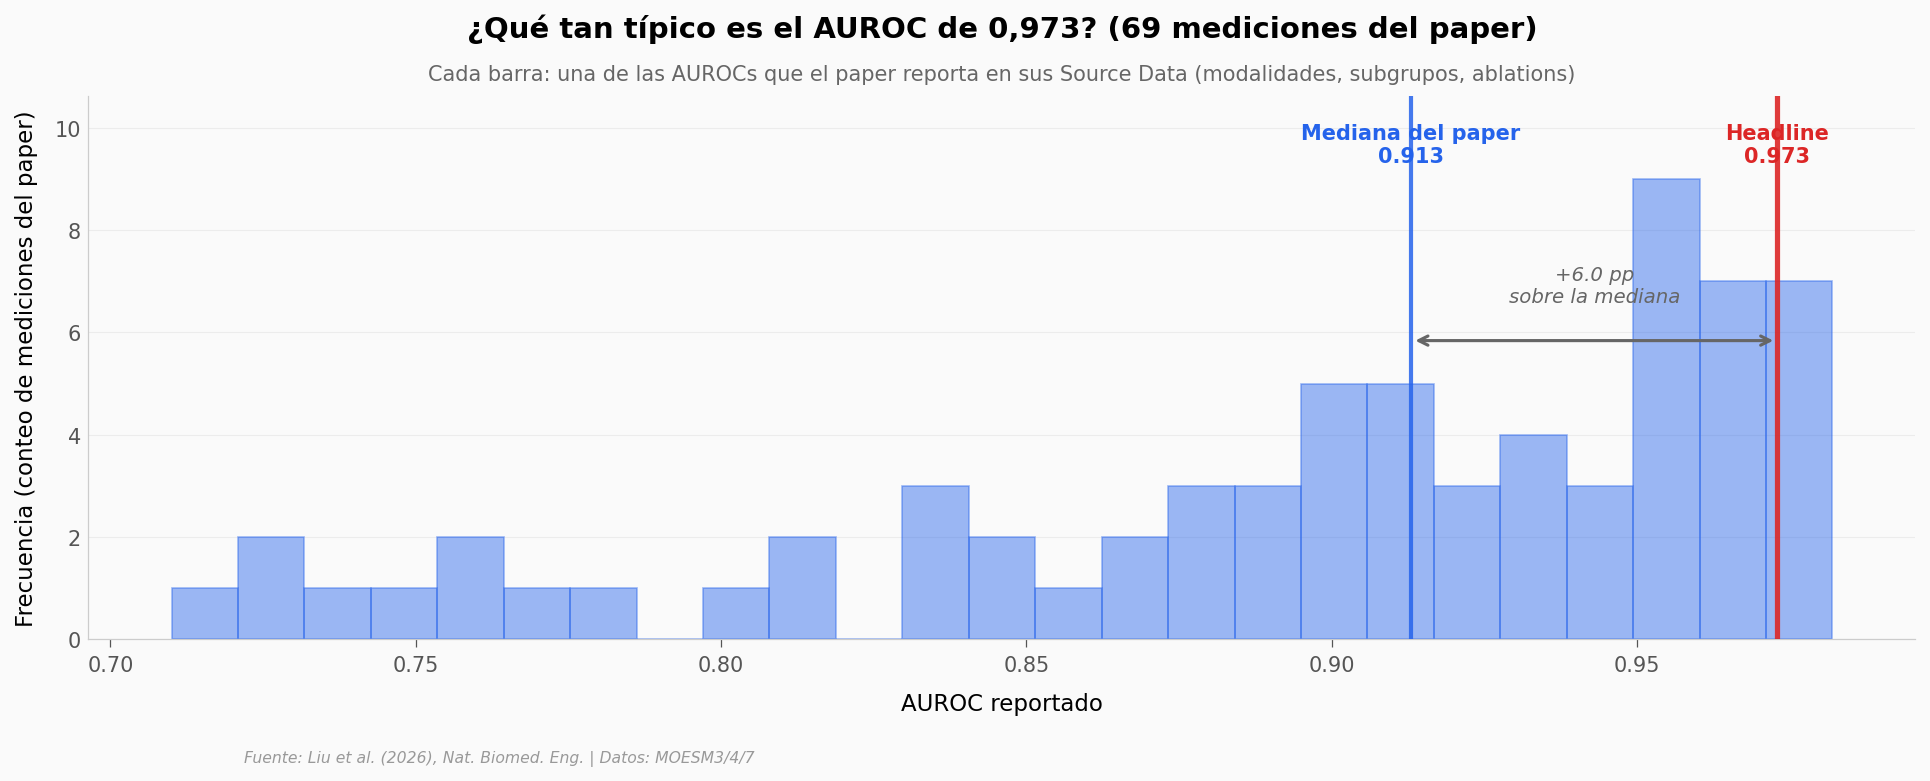


Total de AUROCs reportados: 69
Mediana: 0.913
Headline (Overall, two-stage, full data): 0.973
Diferencia headline − mediana: +6.0 pp


In [5]:
# Gráfica 4 — Distribución de AUROCs reportados en el paper, headline marcado
fig, ax = plt.subplots(figsize=(13, 5))

# Recolectar todos los AUROCs reportados en los Source Data que descargamos
todos_auc = []
todos_auc += modalidad["external_auroc"].tolist()       # 7 valores (US, MM, MRI y combos)
todos_auc += modalidad["internal_auroc"].tolist()       # 7 valores internal
todos_auc += subgrupos["auc_roc"].tolist()              # 13 subgrupos clínicos
todos_auc += subtipo["external_auroc"].tolist()         # 7 subtype external
todos_auc += subtipo["internal_auroc"].tolist()         # 7 subtype internal
todos_auc += eficiencia["us_auroc"].tolist()
todos_auc += eficiencia["mm_auroc"].tolist()
todos_auc += eficiencia["mri_auroc"].tolist()
todos_auc += eficiencia["two_stage_auroc"].tolist()
todos_auc += masking["auroc"].tolist()                  # 8 ablations
todos_auc = np.array(todos_auc)

# Histograma + KDE-like shading
n, bins, _ = ax.hist(todos_auc, bins=25, color=COLOR_DATOS, alpha=0.45,
                     edgecolor=COLOR_DATOS, linewidth=0.8, zorder=2)

mediana = np.median(todos_auc)
ax.axvline(x=mediana, color=COLOR_DATOS, linewidth=2,
           linestyle="-", alpha=0.85, zorder=3)
ax.axvline(x=HEADLINE_AUC, color=COLOR_ALERTA, linewidth=2.5,
           linestyle="-", alpha=0.9, zorder=4)

y_max = n.max() * 1.18
ax.set_ylim(0, y_max)

# Flecha bidireccional entre mediana y headline
ax.annotate("", xy=(HEADLINE_AUC, y_max * 0.55), xytext=(mediana, y_max * 0.55),
            arrowprops=dict(arrowstyle="<->", color="#666666", lw=1.5))
delta = HEADLINE_AUC - mediana
ax.text((mediana + HEADLINE_AUC) / 2, y_max * 0.62,
        f"{delta*100:+.1f} pp\nsobre la mediana",
        ha="center", fontsize=9.5, color="#666666", style="italic")

# Etiquetas verticales
ax.text(mediana, y_max * 0.95, f"Mediana del paper\n{mediana:.3f}",
        color=COLOR_DATOS, fontsize=10, fontweight="bold", ha="center", va="top")
ax.text(HEADLINE_AUC, y_max * 0.95, f"Headline\n{HEADLINE_AUC}",
        color=COLOR_ALERTA, fontsize=10, fontweight="bold", ha="center", va="top")

ax.set_xlabel("AUROC reportado", fontsize=11)
ax.set_ylabel("Frecuencia (conteo de mediciones del paper)", fontsize=11)
ax.set_title(f"¿Qué tan típico es el AUROC de 0,973? ({len(todos_auc)} mediciones del paper)",
             fontsize=14, fontweight="bold", pad=28)
ax.text(0.5, 1.03, "Cada barra: una de las AUROCs que el paper reporta en sus Source Data (modalidades, subgrupos, ablations)",
        transform=ax.transAxes, fontsize=10, color="#666666", ha="center")

fig.text(0.13, -0.03, FUENTE, fontsize=7.5, color="#999999", style="italic")
plt.tight_layout()
plt.savefig("figuras/04_distribucion_aurocs.png", dpi=200, bbox_inches="tight")
plt.show()

print(f"\nTotal de AUROCs reportados: {len(todos_auc)}")
print(f"Mediana: {mediana:.3f}")
print(f"Headline (Overall, two-stage, full data): {HEADLINE_AUC}")
print(f"Diferencia headline − mediana: {(HEADLINE_AUC - mediana)*100:+.1f} pp")

### Lo que los datos soportan

| Afirmación | ¿Soportada? | Detalle |
|---|---|---|
| AUROC overall = 0,973 (CI 0,964–0,981) | ✅ | Verificado fila *Overall* en MOESM4 (fig3c). |
| Ganancia trimodal sobre la mejor unimodal ≈ +4,1 pp | ✅ | 0,950 (US+MM+MRI) − 0,909 (MRI sola) en external validation. |
| BI-RADS 4A con CI [0,76–0,97] | ✅ | Ancho del CI = 0,21 — el más amplio de todos los subgrupos. La incertidumbre es mayor justo en el escenario clínicamente más ambiguo. |
| Mamografía alcanza ≈ 0,87 con solo 10% de los datos | ✅ | Verificado en MOESM7 (extend_fig5b_risk). MM se satura mucho antes que ecografía. |
| BINDS reemplaza al radiólogo | ❌ | Ningún experimento del paper lo respalda. Los autores escriben *"highlight the potential"*, no *"demonstrates"*. Es validación retrospectiva, no comparación clínica prospectiva. |

> **Limitaciones del análisis.** Estos son AUROCs sobre cohortes retrospectivas (8 centros + 7 datasets públicos). No hay ensayo clínico prospectivo. El subset que rinde 0,973 es el subset con las tres modalidades disponibles — en escenarios reales muchas pacientes solo tienen una.

## Ahora tú

1. **¿Cómo se ve la distribución si filtras solo los AUROCs de validación externa?** Pista: `external_only = modalidad["external_auroc"].tolist() + subgrupos["auc_roc"].tolist()`.
2. **¿Cuál es la modalidad cuyo AUROC sube *más* con más datos?** Calcula `df["mri_auroc"].iloc[-1] - df["mri_auroc"].iloc[0]` para cada serie de `eficiencia`.
3. **¿Qué pasa si excluyes los AUCs de ablations?** ¿Sube o baja la mediana? ¿Cambia tu lectura del headline?

In [6]:
# --- EXPERIMENTA AQUÍ ---
# Responde la pregunta 2: ¿cuál modalidad gana más con datos adicionales?
deltas = {
    "Ecografía (US)": eficiencia["us_auroc"].iloc[-1] - eficiencia["us_auroc"].iloc[0],
    "Mamografía (MM)": eficiencia["mm_auroc"].iloc[-1] - eficiencia["mm_auroc"].iloc[0],
    "Resonancia (MRI)": eficiencia["mri_auroc"].iloc[-1] - eficiencia["mri_auroc"].iloc[0],
    "Two-stage": eficiencia["two_stage_auroc"].iloc[-1] - eficiencia["two_stage_auroc"].iloc[0],
}
print("Ganancia de AUROC al ir de 10% a 100% de datos:\n")
for modalidad_nombre, delta in sorted(deltas.items(), key=lambda kv: -kv[1]):
    print(f"  {modalidad_nombre:30s}  +{delta*100:.1f} pp")

print("\nLa ecografía (modalidad más simple) es la que más gana con más datos.")
print("La mamografía se satura casi de inmediato — la señal está en la imagen, no en el volumen.")

Ganancia de AUROC al ir de 10% a 100% de datos:

  Ecografía (US)                  +18.9 pp
  Two-stage                       +11.0 pp
  Resonancia (MRI)                +9.1 pp
  Mamografía (MM)                 +4.3 pp

La ecografía (modalidad más simple) es la que más gana con más datos.
La mamografía se satura casi de inmediato — la señal está en la imagen, no en el volumen.


---

## Fuentes


**Paper**: [A deep learning system for non-invasive breast cancer diagnosis with multimodal data](https://doi.org/10.1038/s41551-026-01654-2)  
*Nature Biomedical Engineering, 2026-05-19*

**Source Data (Supplementary)**:
- [MOESM3 — Source Data Fig 2 (ROC curves single modality + AUROC summaries US/MM/MRI views)](https://static-content.springer.com/esm/art%3A10.1038%2Fs41551-026-01654-2/MediaObjects/41551_2026_1654_MOESM3_ESM.xlsx)
- [MOESM4 — Source Data Fig 3 (bimodal/two-stage ROC + radar plots + BI-RADS subgroup performance)](https://static-content.springer.com/esm/art%3A10.1038%2Fs41551-026-01654-2/MediaObjects/41551_2026_1654_MOESM4_ESM.xlsx)
- [MOESM7 — Source Data Extended Fig 5 (transformer ablations + training data fraction + alignment/masking ablations)](https://static-content.springer.com/esm/art%3A10.1038%2Fs41551-026-01654-2/MediaObjects/41551_2026_1654_MOESM7_ESM.xlsx)

**Código de referencia**: [lyhkevin/BINDS — PyTorch source code + preprocessing + weights](https://github.com/lyhkevin/BINDS)

*18 afirmaciones del notebook verificadas contra estas fuentes*

**Licencia.** Notebook bajo CC BY 4.0. Datos del paper: ver Springer Nature Source Data terms. Código de BINDS: MIT (ver [GitHub](https://github.com/lyhkevin/BINDS)).

**Repositorio del Lab.** [github.com/Ciencia-a-Mordiscos/lab](https://github.com/Ciencia-a-Mordiscos/lab)

*Notebook generado por Ciencia a Mordiscos — Lab. Si encuentras un error, abre un issue.*